In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **1. Loading Data**

In [3]:
df = pd.read_csv("data/train.csv")
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


### **2.Describing the data**

In [4]:
print(df.shape)
df.describe()

(1460, 81)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### **3. Missing Count Check**

**Here it can be seen some columns have more than 80 percent of data missing**
Example :
*         Alley
*         PoolQc
*         Fence
*         MiscFeature


In [5]:
df.isna().sum()
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
missing = df.isnull().sum()
miss_col_list = list(missing[missing > 0].index)


n = missing[missing > 0]
print(n)


LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
# Each column unique value check

for col in df.columns:
    u = df[col].unique()
    print(f"{col} : {u}")
    print()

Id : [   1    2    3 ... 1458 1459 1460]

MSSubClass : [ 60  20  70  50 190  45  90 120  30  85  80 160  75 180  40]

MSZoning : ['RL' 'RM' 'C (all)' 'FV' 'RH']

LotFrontage : [ 65.  80.  68.  60.  84.  85.  75.  nan  51.  50.  70.  91.  72.  66.
 101.  57.  44. 110.  98.  47. 108. 112.  74. 115.  61.  48.  33.  52.
 100.  24.  89.  63.  76.  81.  95.  69.  21.  32.  78. 121. 122.  40.
 105.  73.  77.  64.  94.  34.  90.  55.  88.  82.  71. 120. 107.  92.
 134.  62.  86. 141.  97.  54.  41.  79. 174.  99.  67.  83.  43. 103.
  93.  30. 129. 140.  35.  37. 118.  87. 116. 150. 111.  49.  96.  59.
  36.  56. 102.  58.  38. 109. 130.  53. 137.  45. 106. 104.  42.  39.
 144. 114. 128. 149. 313. 168. 182. 138. 160. 152. 124. 153.  46.]

LotArea : [ 8450  9600 11250 ... 17217 13175  9717]

Street : ['Pave' 'Grvl']

Alley : [nan 'Grvl' 'Pave']

LotShape : ['Reg' 'IR1' 'IR2' 'IR3']

LandContour : ['Lvl' 'Bnk' 'Low' 'HLS']

Utilities : ['AllPub' 'NoSeWa']

LotConfig : ['Inside' 'FR2' 'Corner' 'C

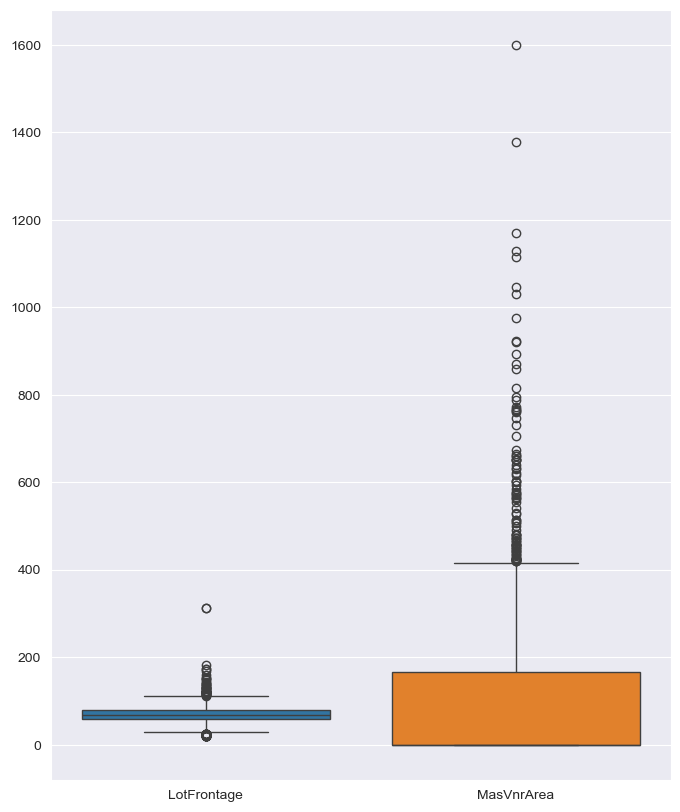

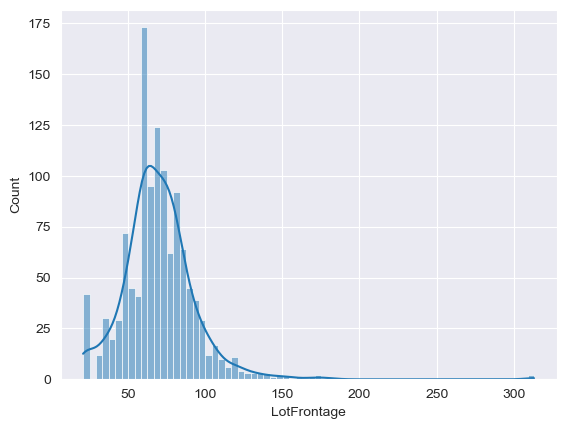

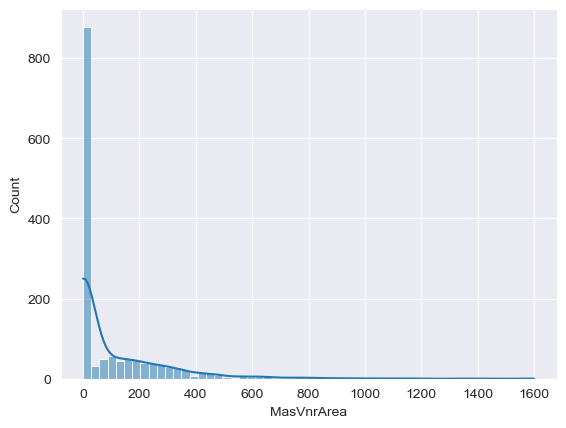

In [9]:
# Checking Outliers

plt.figure(figsize=(8,10))
sns.boxplot(data=df[["LotFrontage" , "MasVnrArea"]])
plt.show()

sns.histplot(df['LotFrontage'], kde=True)
plt.show()

sns.histplot(df['MasVnrArea'], kde=True)
plt.show()

In [10]:
# Transforming features as they contain outliers

# LotFrontage
# As data is right skewed so using log transform log1p(x)
df["Log_LotFrontage"] = np.log1p(df["LotFrontage"])

# MasVnrArea
# As data is highly right skewed so using log transform log1p(x)

df["Log_MasVnrArea"] = np.log1p(df["MasVnrArea"])


In [11]:
# ==========================================================
# Filling Missing Values
# ==========================================================


# ==========================================================
# 1. LotFrontage
# ==========================================================
# Since LotFrontage depends heavily on the Neighborhood and
# somewhat on the type of house (MSSubClass), we impute the
# LOG TRANSFORMED LotFrontage values using hierarchical means.
#
# NOTE:
# We are working on Log_LotFrontage.
# Original LotFrontage NaNs are intentionally kept as-is.
# ==========================================================

# Fill using MSSubClass + Neighborhood mean
df['Log_LotFrontage'] = (
    df.groupby(['MSSubClass', 'Neighborhood'])['Log_LotFrontage']
    .transform(lambda x: x.fillna(x.mean()))
)

# Fill remaining NaNs using Neighborhood mean
df['Log_LotFrontage'] = (
    df.groupby('Neighborhood')['Log_LotFrontage']
    .transform(lambda x: x.fillna(x.mean()))
)

# Final fallback using overall median
df['Log_LotFrontage'] = (
    df['Log_LotFrontage']
    .fillna(df['Log_LotFrontage'].median())
)


# ==========================================================
# 2. MasVnrArea and MasVnrType
# ==========================================================
# Cases:
#
# a. Both MasVnrType and Log_MasVnrArea are missing
#    → No masonry veneer exists
#
# b. MasVnrType exists but Log_MasVnrArea is missing
#    → Fill area using median area of that veneer type
#
# c. Entire MasVnrType group has missing area
#    → Fill remaining values using overall median
#
# NOTE:
# We are working on Log_MasVnrArea.
# Original MasVnrArea NaNs are intentionally kept as-is.
# ==========================================================

# a. Both Type and Area are missing
mask = (
        df['MasVnrType'].isna() &
        df['Log_MasVnrArea'].isna()
)

df.loc[mask, 'MasVnrType'] = 'None'
df.loc[mask, 'Log_MasVnrArea'] = 0.0      # log1p(0) = 0


# b. Type exists but area is missing
df['Log_MasVnrArea'] = (
    df.groupby('MasVnrType')['Log_MasVnrArea']
    .transform(lambda x: x.fillna(x.median()))
)


# c. Final fallback
df['Log_MasVnrArea'] = (
    df['Log_MasVnrArea']
    .fillna(df['Log_MasVnrArea'].median())
)


# ==========================================================
# 3. Fill "None" for categorical columns
# ==========================================================
# Missing values in these columns imply that the feature
# does not exist rather than data being unavailable.
#
# NOTE:
# LotFrontage and MasVnrArea are excluded because we are
# handling their LOG transformed versions separately.
# ==========================================================

except_col_list = [
    'GarageYrBlt',
    'Electrical',
    'GarageCond',
    'GarageQual',
    'GarageFinish'
]

for col in miss_col_list:
    if col not in except_col_list:
        df[col] = df[col].fillna('None')


# ==========================================================
# 4. Electrical
# ==========================================================
# Houses belonging to the same MSSubClass are more likely
# to have similar electrical systems.
#
# Fill using mode within MSSubClass.
# If a particular subclass has no valid mode,
# use the overall mode.
# ==========================================================

df['Electrical'] = (
    df.groupby('MSSubClass')['Electrical']
    .transform(
        lambda x: x.fillna(
            x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )
)

# Final fallback
df['Electrical'] = (
    df['Electrical']
    .fillna(df['Electrical'].mode()[0])
)


# ==========================================================
# 5. GarageFinish, GarageQual, GarageCond
# ==========================================================
# Cases:
#
# a. GarageType missing
#    → No garage exists
#    → Fill all garage categorical attributes with 'None'
#
# b. GarageType exists
#    → Fill missing values using mode within GarageType
#
# c. If entire GarageType group is missing
#    → Fill using overall mode
# ==========================================================

garage_cols = [
    'GarageFinish',
    'GarageQual',
    'GarageCond'
]


# a. No Garage
mask = df['GarageType'].isna()

for col in garage_cols:
    df.loc[mask, col] = 'None'


# b. Garage exists
for col in garage_cols:
    df[col] = (
        df.groupby('GarageType')[col]
        .transform(
            lambda x: x.fillna(
                x.mode().iloc[0] if not x.mode().empty else np.nan
            )
        )
    )


# c. Final fallback
for col in garage_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


# ==========================================================
# 6. GarageYrBlt
# ==========================================================
# Cases:
#
# a. GarageType missing
#    → No garage exists
#    → GarageYrBlt = 0
#
# b. Garage exists but GarageYrBlt is missing
#    → Use YearRemodAdd
#
# Reason:
# If no remodeling occurred:
#     YearRemodAdd == YearBuilt
#
# If remodeling occurred:
#     The garage may have been added/modified during remodeling.
# ==========================================================

# a. No garage
mask = df['GarageType'].isna()

df.loc[mask, 'GarageYrBlt'] = 0


# b. Garage exists but year missing
mask = (
        df['GarageYrBlt'].isna() &
        df['GarageType'].notna()
)

df.loc[mask, 'GarageYrBlt'] = (
    df.loc[mask, 'YearRemodAdd']
)


## Dropping the Old columns

df.drop(columns=['LotFrontage', 'MasVnrArea'], inplace=True)

# ==========================================================
# 7. Verify remaining missing values
# ==========================================================

remaining_na = df.isna().sum()
remaining_na = remaining_na[remaining_na > 0]

print(remaining_na)


Series([], dtype: int64)


C:\Users\Rupali Waghmare\AppData\Local\Temp\ipykernel_14888\3751603797.py:166: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(
C:\Users\Rupali Waghmare\AppData\Local\Temp\ipykernel_14888\3751603797.py:166: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(
C:\Users\Rupali Waghmare\AppData\Local\Temp\ipykernel_14888\3751603797.py:166: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the fu

In [12]:
# Converting the datatype of the columns to category

for col in miss_col_list:
    if col not in ["LotFrontage" , "MasVnrArea"]:
        df[col]= df[col].astype('category')

for col in df.columns:
    if col in miss_col_list:
        print(df[col].dtype)

category
category
category
category
category
category
category
category
category
category
category
category
category
category
category
category
category


### **Feature Engineering**

In [13]:
l = ["YrSold" , "YearBuilt" , "GarageYrBlt" , "YearRemodAdd"]
for col in l:
    df[col] = df[col].astype("int64") # .astype doesnt modify dataframe in place

# HouseAge
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

# GarageAge
df["GarageAge"] = np.where(
    df["GarageYrBlt"] == 0,
    0,
    df["YrSold"] - df["GarageYrBlt"]
)

# RemodelAge
df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]

# Total Bathrooms
df["TotalBathrooms"] = (
        df["FullBath"]
        + 0.5 * df["HalfBath"]
        + df["BsmtFullBath"]
        + 0.5 * df["BsmtHalfBath"]
)

# Total Porch Area
df["TotalPorchSF"] = (
        df["OpenPorchSF"]
        + df["EnclosedPorch"]
        + df["3SsnPorch"]
        + df["ScreenPorch"]
)

# Total Living Area
df["TotalSF"] = (
        df["TotalBsmtSF"]
        + df["1stFlrSF"]
        + df["2ndFlrSF"]
)

# Total Outside Area
df["TotalOutsideSF"] = (
        df["WoodDeckSF"]
        + df["OpenPorchSF"]
        + df["EnclosedPorch"]
        + df["3SsnPorch"]
        + df["ScreenPorch"]
)

# Has Garage
df["HasGarage"] = (df["GarageArea"] > 0).astype(int)

# Has Basement
df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)

# Has Fireplace
df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)

### **Encoding**

In [14]:
# Label encoding

# Ordinal Columns (Label Encoding)

# ===========================
# ORDINAL ENCODING MAPPINGS
# ===========================

# Quality/Condition Columns
quality_cols = [
    'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual', 'GarageCond',
    'PoolQC'
]

quality_map = {
    'None': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}

for col in quality_cols:
    df[col] = df[col].map(quality_map)


# ===========================
# Overall Quality & Condition
# ===========================

# Already numeric, no encoding needed

# OverallQual
# OverallCond


# ===========================
# Basement Exposure
# ===========================

exposure_map = {
    'None': 0,
    'No': 1,
    'Mn': 2,
    'Av': 3,
    'Gd': 4
}

df['BsmtExposure'] = df['BsmtExposure'].map(exposure_map)


# ===========================
# Basement Finish Type
# ===========================

fin_map = {
    'None': 0,
    'Unf': 1,
    'LwQ': 2,
    'Rec': 3,
    'BLQ': 4,
    'ALQ': 5,
    'GLQ': 6
}

df['BsmtFinType1'] = df['BsmtFinType1'].map(fin_map)
df['BsmtFinType2'] = df['BsmtFinType2'].map(fin_map)


# ===========================
# Garage Finish
# ===========================

garage_finish_map = {
    'None': 0,
    'Unf': 1,
    'RFn': 2,
    'Fin': 3
}

df['GarageFinish'] = df['GarageFinish'].map(garage_finish_map)


# ===========================
# Paved Drive
# ===========================

paved_map = {
    'N': 0,
    'P': 1,
    'Y': 2
}

df['PavedDrive'] = df['PavedDrive'].map(paved_map)


# ===========================
# Fence
# ===========================

fence_map = {
    'None': 0,
    'MnWw': 1,
    'GdWo': 2,
    'MnPrv': 3,
    'GdPrv': 4
}

df['Fence'] = df['Fence'].map(fence_map)


# ===========================
# NOMINAL ENCODING
# ===========================

nominal_cols = [
    'MSZoning', 'Street', 'Alley',
    'LotShape', 'LandContour', 'Utilities',
    'LotConfig', 'LandSlope',
    'Neighborhood',
    'Condition1', 'Condition2',
    'BldgType', 'HouseStyle',
    'RoofStyle', 'RoofMatl',
    'Exterior1st', 'Exterior2nd',
    'MasVnrType',
    'Foundation',
    'Heating',
    'CentralAir',
    'Electrical',
    'Functional',
    'GarageType',
    'MiscFeature',
    'SaleType',
    'SaleCondition'
]

df = pd.get_dummies(
    df,
    columns=nominal_cols,
    drop_first=True,
    dtype=int
)


TotalSF             0.677698
OverallQual         0.562397
GrLivArea           0.481823
GarageCars          0.368938
GarageArea          0.366586
TotalBsmtSF         0.364713
HouseAge            0.345237
TotalBathrooms      0.329037
BsmtQual            0.327780
KitchenQual         0.326472
ExterQual           0.320815
1stFlrSF            0.309754
MSSubClass          0.280063
FullBath            0.267818
RemodelAge          0.258624
YearRemodAdd        0.241750
GarageFinish        0.238800
GarageAge           0.237052
Log_LotFrontage     0.232748
TotRmsAbvGrd        0.225198
FireplaceQu         0.205860
2ndFlrSF            0.201365
HeatingQC           0.171511
Foundation_PConc    0.170629
HasFireplace        0.169398
Fireplaces          0.160826
LotArea             0.159227
BsmtFinSF1          0.149369
BsmtFinType1        0.144940
OpenPorchSF         0.144133
dtype: float64


Text(0, 0.5, 'Features')

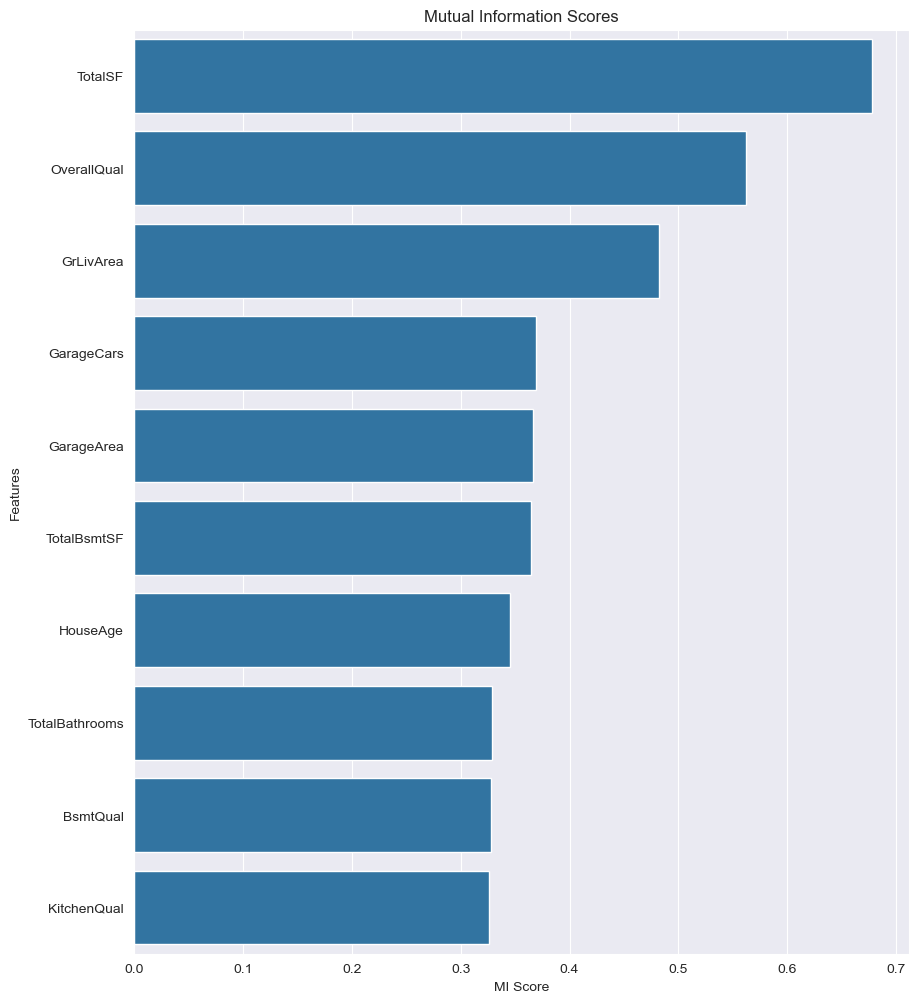

In [15]:
df.drop(columns=["YrSold" , "GarageYrBlt" , "YearBuilt"] , inplace=True)


from sklearn.feature_selection import mutual_info_regression

# Evaluating Mutual Information

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

mi_scores = mutual_info_regression(X, y)

mi_scores = pd.Series(mi_scores, index=X.columns)

x = mi_scores.sort_values(ascending=False)

print(x.head(30))


## Graph

top_10 = x.head(10)
plt.figure(figsize=(10, 12))

sns.barplot(
    x=top_10.values,
    y=top_10.index
)

plt.title("Mutual Information Scores")
plt.xlabel("MI Score")
plt.ylabel("Features")


In [16]:
df.to_csv('data/Housing_data_cleaned.csv')

In [17]:
# Scaling "TotalSF" and "GrLivArea"  and "OverallQual" for using in kmeans

from sklearn.preprocessing import StandardScaler

X = df[["TotalSF" , "OverallQual" , "GrLivArea"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### **K Means**

C:\Users\Rupali Waghmare\miniconda3\envs\AI_ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Rupali Waghmare\miniconda3\envs\AI_ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Rupali Waghmare\miniconda3\envs\AI_ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Rupali Waghmare\miniconda3\envs\AI_ML\Lib\site-packages\sklea

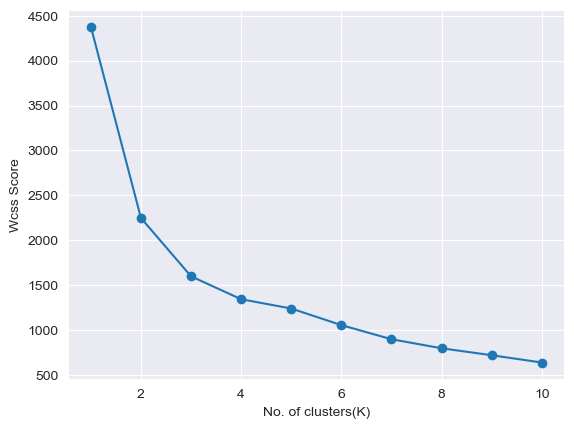

In [18]:
from sklearn.cluster import KMeans



# Using Elbow method for deciding no. of clusters
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i , init="k-means++" , random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11) , wcss , marker = 'o')
plt.xlabel("No. of clusters(K)")
plt.ylabel("Wcss Score")
plt.show()

C:\Users\Rupali Waghmare\miniconda3\envs\AI_ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Rupali Waghmare\miniconda3\envs\AI_ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Rupali Waghmare\miniconda3\envs\AI_ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Rupali Waghmare\miniconda3\envs\AI_ML\Lib\site-packages\sklea

Text(0, 0.5, 'Silhouette_score')

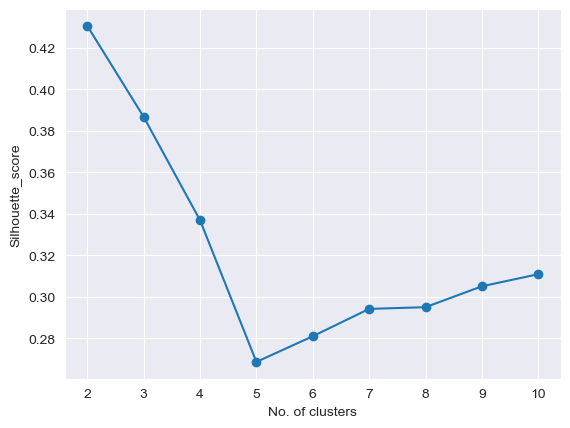

In [19]:
from sklearn.metrics import silhouette_score

k = []
score = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=i , init="k-means++" , random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    k.append(i)
    score.append(silhouette_score(X_scaled,labels))

plt.plot(k , score , marker='o')
plt.xlabel("No. of clusters")
plt.ylabel("Silhouette_score")

In [20]:
# By both method we can conclude that at K = 2 the Wcss score is less and also the silhouette score is the highest

# Clustering with k = 2

kmeans = KMeans(n_clusters=2 , init= "k-means++" , n_init=10 , max_iter=300 , random_state=42 , algorithm='lloyd')

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(kmeans.cluster_centers_)
print()
print(kmeans.inertia_)


[[ 0.84926078  0.8241572   0.83580524]
 [-0.590833   -0.57336837 -0.58147194]]

2247.892018144901


C:\Users\Rupali Waghmare\miniconda3\envs\AI_ML\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [21]:
df.to_csv("data/Features_engineered_Housing_Dataset.csv")